<a href="https://colab.research.google.com/github/AbdullahScripts/CropChain-Model-Comparison/blob/main/CropChain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

zip_path = "/content/drive/MyDrive/CropChain/rice_leaf_dataset.zip"

print(os.path.exists(zip_path))
print(os.path.getsize(zip_path))

True
308802277


In [3]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/CropChain/rice_leaf_dataset.zip"
extract_path = "/content/rice_dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [4]:
import os

print(os.listdir('/content/rice_dataset'))

['RiceLeafsDisease']


In [5]:
dataset_path = "/content/rice_dataset"

for item in os.listdir(dataset_path):
    print(item)

RiceLeafsDisease


In [6]:
import os

dataset_path = "/content/rice_dataset/RiceLeafsDisease"

print(os.listdir(dataset_path))

['validation', 'train']


In [7]:
import os

train_path = "/content/rice_dataset/RiceLeafsDisease/train"

classes = os.listdir(train_path)

print("Number of classes:", len(classes))
print(classes)

Number of classes: 6
['brown_spot', 'bacterial_leaf_blight', 'leaf_blast', 'leaf_scald', 'healthy', 'narrow_brown_spot']


In [8]:
import os

train_path = "/content/rice_dataset/RiceLeafsDisease/train"

for cls in os.listdir(train_path):
    path = os.path.join(train_path, cls)
    print(f"{cls}: {len(os.listdir(path))}")

brown_spot: 350
bacterial_leaf_blight: 350
leaf_blast: 350
leaf_scald: 350
healthy: 350
narrow_brown_spot: 350


In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

train_dir = "/content/rice_dataset/RiceLeafsDisease/train"
val_dir = "/content/rice_dataset/RiceLeafsDisease/validation"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 2100 images belonging to 6 classes.
Found 528 images belonging to 6 classes.


In [10]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

print("MobileNetV2 loaded successfully!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MobileNetV2 loaded successfully!


In [11]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(6, activation='softmax')(x)

model = Model(
    inputs=base_model.input,
    outputs=outputs
)

print("Classification head added successfully!")

Classification head added successfully!


In [12]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [13]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    verbose=1
)

print("Callbacks created successfully!")

Callbacks created successfully!


In [15]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.5657 - loss: 1.1063 - val_accuracy: 0.7348 - val_loss: 0.6933 - learning_rate: 0.0010
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 50s 766ms/step - accuracy: 0.7586 - loss: 0.6503 - val_accuracy: 0.8163 - val_loss: 0.5160 - learning_rate: 0.0010
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 49s 743ms/step - accuracy: 0.8033 - loss: 0.5252 - val_accuracy: 0.8523 - val_loss: 0.4450 - learning_rate: 0.0010
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 50s 763ms/step - accuracy: 0.8424 - loss: 0.4491 - val_accuracy: 0.8712 - val_loss: 0.3947 - learning_rate: 0.0010
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 50s 759ms/step - accuracy: 0.8443 - loss: 0.4225 - val_accuracy: 0.8826 - val_loss: 0.3570 - learning_rate: 0.0010
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 85s 812ms/step - accuracy: 0.8605 - loss: 0.3820 - val_accuracy: 0.8958 - val_loss: 0.3311 - learning_rate: 0.0010
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 48s 733ms/step - accuracy: 0.8748 - loss: 0.34

In [16]:
loss, accuracy = model.evaluate(val_generator)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 359ms/step - accuracy: 0.9356 - loss: 0.2111
Validation Loss: 0.2111
Validation Accuracy: 0.9356


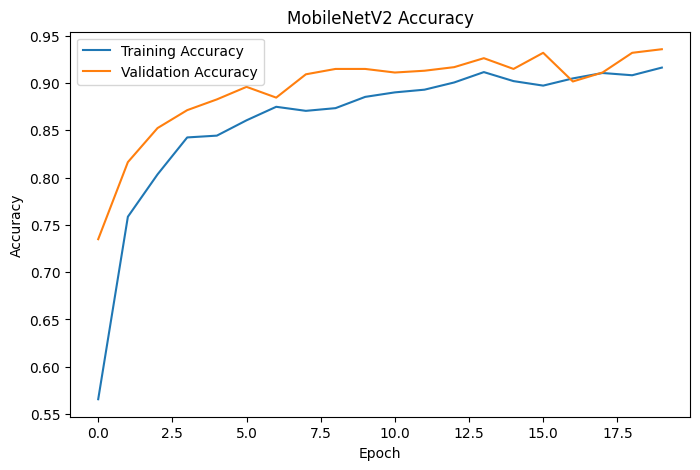

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('MobileNetV2 Accuracy')
plt.legend()
plt.show()

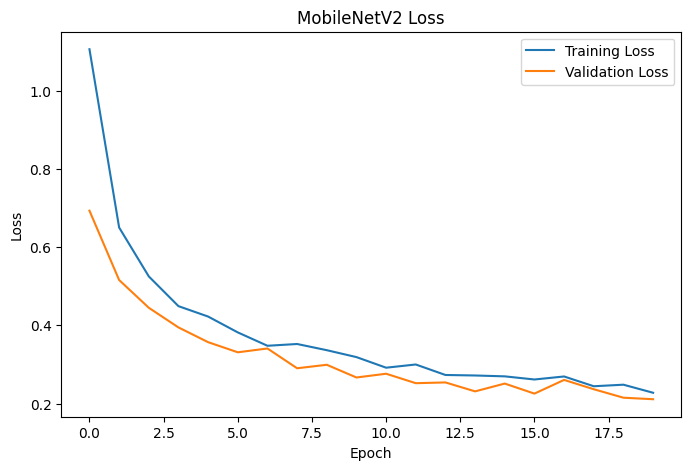

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MobileNetV2 Loss')
plt.legend()
plt.show()

In [19]:
import numpy as np

val_generator.reset()

predictions = model.predict(val_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes

print("Predictions generated successfully!")
print("Total predictions:", len(y_pred))

17/17 ━━━━━━━━━━━━━━━━━━━━ 17s 744ms/step
Predictions generated successfully!
Total predictions: 528


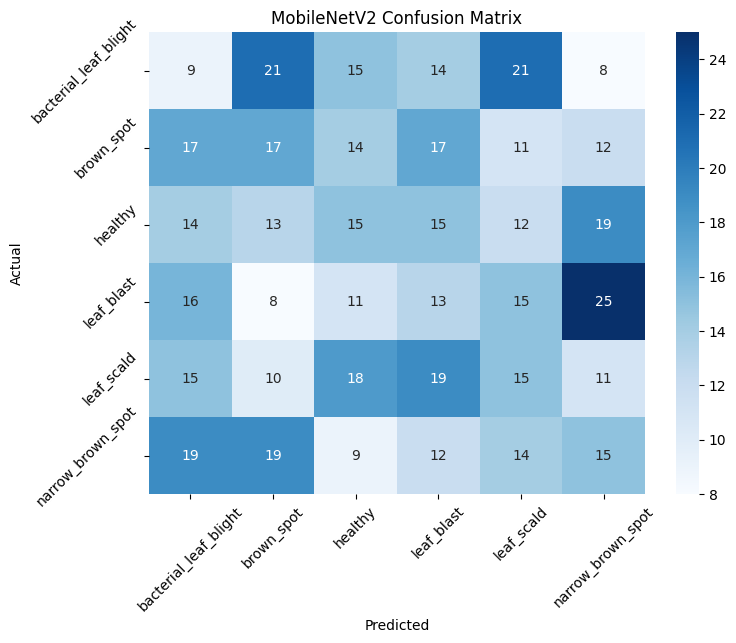

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class_names = list(val_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('MobileNetV2 Confusion Matrix')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

In [21]:
val_generator_cm = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 528 images belonging to 6 classes.


In [22]:
import numpy as np

predictions = model.predict(val_generator_cm)

y_pred = np.argmax(predictions, axis=1)
y_true = val_generator_cm.classes

print("Total predictions:", len(y_pred))
print("Total labels:", len(y_true))

17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 333ms/step
Total predictions: 528
Total labels: 528


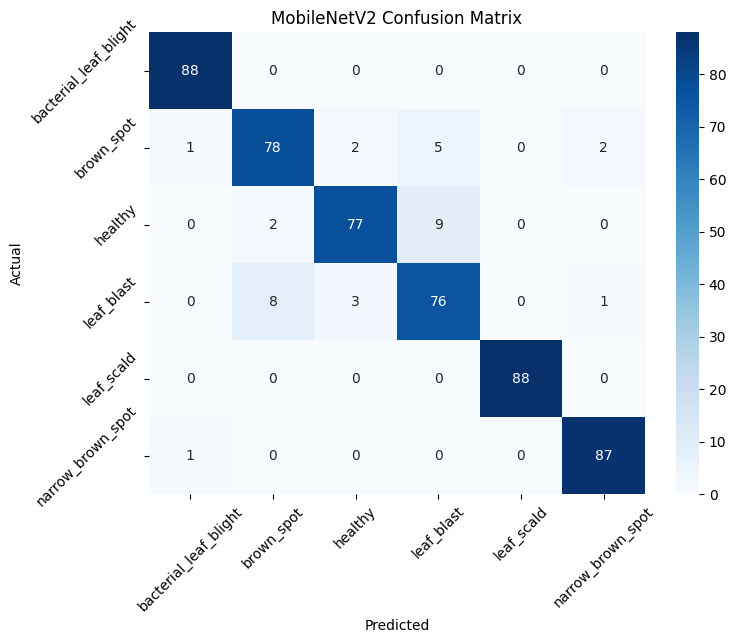

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class_names = list(val_generator_cm.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('MobileNetV2 Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

In [24]:
from sklearn.metrics import classification_report

class_names = list(val_generator_cm.class_indices.keys())

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

                       precision    recall  f1-score   support

bacterial_leaf_blight       0.98      1.00      0.99        88
           brown_spot       0.89      0.89      0.89        88
              healthy       0.94      0.88      0.91        88
           leaf_blast       0.84      0.86      0.85        88
           leaf_scald       1.00      1.00      1.00        88
    narrow_brown_spot       0.97      0.99      0.98        88

             accuracy                           0.94       528
            macro avg       0.94      0.94      0.94       528
         weighted avg       0.94      0.94      0.94       528



In [25]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

print("EfficientNetB0 loaded successfully!")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
EfficientNetB0 loaded successfully!


In [26]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(6, activation='softmax')(x)

model = Model(
    inputs=base_model.input,
    outputs=outputs
)

print("Classification head added successfully!")

Classification head added successfully!


In [27]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("EfficientNetB0 compiled successfully!")

EfficientNetB0 compiled successfully!


In [28]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [29]:
# Show only parameter counts
print("Total parameters:", model.count_params())

trainable = sum([layer.count_params() for layer in model.layers if layer.trainable])
non_trainable = sum([layer.count_params() for layer in model.layers if not layer.trainable])

print("Trainable parameters:", trainable)
print("Non-trainable parameters:", non_trainable)

Total parameters: 4057257
Trainable parameters: 7686
Non-trainable parameters: 4049571


In [30]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3
    ),

    ModelCheckpoint(
        'best_efficientnet.keras',
        monitor='val_loss',
        save_best_only=True
    )
]

print("Callbacks created successfully!")

Callbacks created successfully!


In [32]:
print(train_generator)
print(val_generator_cm)

In [33]:
history_eff = model.fit(
    train_generator,
    validation_data=val_generator_cm,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.1543 - loss: 1.8271 - val_accuracy: 0.1667 - val_loss: 1.8216 - learning_rate: 0.0010
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 50s 756ms/step - accuracy: 0.1690 - loss: 1.8189 - val_accuracy: 0.1667 - val_loss: 1.8046 - learning_rate: 0.0010
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 49s 738ms/step - accuracy: 0.1600 - loss: 1.8194 - val_accuracy: 0.1667 - val_loss: 1.8263 - learning_rate: 0.0010
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 50s 763ms/step - accuracy: 0.1748 - loss: 1.8149 - val_accuracy: 0.1667 - val_loss: 1.8031 - learning_rate: 0.0010
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 51s 774ms/step - accuracy: 0.1571 - loss: 1.8305 - val_accuracy: 0.1667 - val_loss: 1.8019 - learning_rate: 0.0010
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 54s 821ms/step - accuracy: 0.1590 - loss: 1.8228 - val_accuracy: 0.1667 - val_loss: 1.8229 - learning_rate: 0.0010
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 48s 735ms/step - accuracy: 0.1743 - loss: 1.81

In [34]:
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

val_datagen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator_eff = train_datagen_eff.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_generator_eff = val_datagen_eff.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2100 images belonging to 6 classes.
Found 528 images belonging to 6 classes.


In [35]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.3)(x)
output = Dense(6, activation='softmax')(x)

model = Model(base_model.input, output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [36]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.3)(x)
outputs = Dense(6, activation='softmax')(x)

model = Model(
    inputs=base_model.input,
    outputs=outputs
)

print("EfficientNetB0 rebuilt successfully!")

EfficientNetB0 rebuilt successfully!


In [37]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [38]:
history_eff = model.fit(
    train_generator_eff,
    validation_data=val_generator_eff,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 74s 788ms/step - accuracy: 0.6067 - loss: 1.0990 - val_accuracy: 0.7727 - val_loss: 0.7202 - learning_rate: 0.0010
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 48s 443ms/step - accuracy: 0.7938 - loss: 0.6254 - val_accuracy: 0.8447 - val_loss: 0.5278 - learning_rate: 0.0010
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 439ms/step - accuracy: 0.8514 - loss: 0.4850 - val_accuracy: 0.8617 - val_loss: 0.4446 - learning_rate: 0.0010
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 439ms/step - accuracy: 0.8695 - loss: 0.4090 - val_accuracy: 0.8902 - val_loss: 0.3768 - learning_rate: 0.0010
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 28s 427ms/step - accuracy: 0.8910 - loss: 0.3644 - val_accuracy: 0.9053 - val_loss: 0.3408 - learning_rate: 0.0010
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 28s 432ms/step - accuracy: 0.8952 - loss: 0.3280 - val_accuracy: 0.9091 - val_loss: 0.3009 - learning_rate: 0.0010
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 441ms/step - accuracy: 0.9005 - loss: 0.

In [39]:
loss, acc = model.evaluate(val_generator_eff)

print("Validation Loss:", round(loss,4))
print("Validation Accuracy:", round(acc,4))

17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 356ms/step - accuracy: 0.9432 - loss: 0.1612
Validation Loss: 0.1612
Validation Accuracy: 0.9432


In [40]:
import numpy as np

predictions = model.predict(val_generator_eff)

y_pred = np.argmax(predictions, axis=1)
y_true = val_generator_eff.classes

print("Predictions:", len(y_pred))
print("Ground truth:", len(y_true))

17/17 ━━━━━━━━━━━━━━━━━━━━ 23s 949ms/step
Predictions: 528
Ground truth: 528


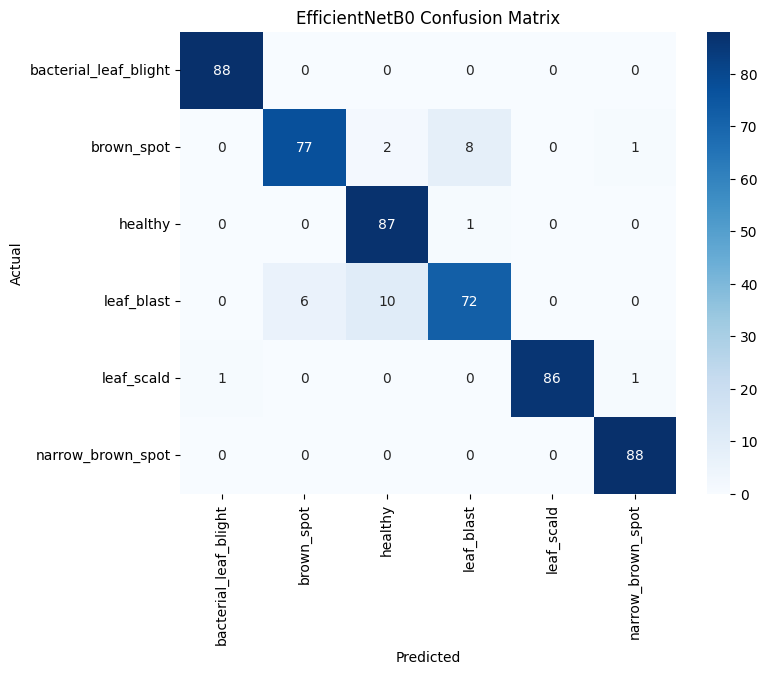

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=list(val_generator_eff.class_indices.keys()),
    yticklabels=list(val_generator_eff.class_indices.keys())
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('EfficientNetB0 Confusion Matrix')
plt.show()

In [42]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=list(val_generator_eff.class_indices.keys())
    )
)

                       precision    recall  f1-score   support

bacterial_leaf_blight       0.99      1.00      0.99        88
           brown_spot       0.93      0.88      0.90        88
              healthy       0.88      0.99      0.93        88
           leaf_blast       0.89      0.82      0.85        88
           leaf_scald       1.00      0.98      0.99        88
    narrow_brown_spot       0.98      1.00      0.99        88

             accuracy                           0.94       528
            macro avg       0.94      0.94      0.94       528
         weighted avg       0.94      0.94      0.94       528



In [43]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

print("ResNet50 loaded successfully!")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
ResNet50 loaded successfully!


In [44]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(6, activation='softmax')(x)

model = Model(
    inputs=base_model.input,
    outputs=outputs
)

print("Classification head added successfully!")

Classification head added successfully!


In [45]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("ResNet50 compiled successfully!")

ResNet50 compiled successfully!


In [46]:
print("Total parameters:", model.count_params())

trainable = sum(
    [layer.count_params() for layer in model.layers if layer.trainable]
)

non_trainable = sum(
    [layer.count_params() for layer in model.layers if not layer.trainable]
)

print("Trainable parameters:", trainable)
print("Non-trainable parameters:", non_trainable)

Total parameters: 23600006
Trainable parameters: 12294
Non-trainable parameters: 23587712


In [47]:
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen_res = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

val_datagen_res = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator_res = train_datagen_res.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_generator_res = val_datagen_res.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2100 images belonging to 6 classes.
Found 528 images belonging to 6 classes.


In [49]:
history_res = model.fit(
    train_generator_res,
    validation_data=val_generator_res,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 31s 476ms/step - accuracy: 0.8371 - loss: 0.4490 - val_accuracy: 0.8769 - val_loss: 0.3708 - learning_rate: 2.0000e-04
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 31s 470ms/step - accuracy: 0.8619 - loss: 0.3982 - val_accuracy: 0.8996 - val_loss: 0.3332 - learning_rate: 2.0000e-04
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 31s 471ms/step - accuracy: 0.8733 - loss: 0.3554 - val_accuracy: 0.9091 - val_loss: 0.3003 - learning_rate: 2.0000e-04
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 32s 480ms/step - accuracy: 0.8838 - loss: 0.3238 - val_accuracy: 0.9091 - val_loss: 0.2946 - learning_rate: 4.0000e-05
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 31s 469ms/step - accuracy: 0.8852 - loss: 0.3146 - val_accuracy: 0.9091 - val_loss: 0.2897 - learning_rate: 4.0000e-05


In [50]:
EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [51]:
print(len(history_res.history['loss']))
print(history_res.history['val_accuracy'])

5
[0.876893937587738, 0.8996211886405945, 0.9090909361839294, 0.9090909361839294, 0.9090909361839294]


In [52]:
history_res2 = model.fit(
    train_generator_res,
    validation_data=val_generator_res,
    initial_epoch=5,
    epochs=20,
    callbacks=callbacks
)

Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 31s 472ms/step - accuracy: 0.8514 - loss: 0.4054 - val_accuracy: 0.8845 - val_loss: 0.3581 - learning_rate: 4.0000e-05
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 30s 449ms/step - accuracy: 0.8729 - loss: 0.3930 - val_accuracy: 0.8920 - val_loss: 0.3496 - learning_rate: 4.0000e-05
Epoch 8/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 31s 468ms/step - accuracy: 0.8638 - loss: 0.3804 - val_accuracy: 0.8958 - val_loss: 0.3422 - learning_rate: 4.0000e-05
Epoch 9/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 31s 473ms/step - accuracy: 0.8590 - loss: 0.3815 - val_accuracy: 0.8977 - val_loss: 0.3406 - learning_rate: 8.0000e-06
Epoch 10/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 31s 472ms/step - accuracy: 0.8729 - loss: 0.3803 - val_accuracy: 0.8977 - val_loss: 0.3390 - learning_rate: 8.0000e-06


In [53]:
loss, acc = model.evaluate(val_generator_res)

print("Validation Loss:", round(loss,4))
print("Validation Accuracy:", round(acc,4))

17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 400ms/step - accuracy: 0.8845 - loss: 0.3581
Validation Loss: 0.3581
Validation Accuracy: 0.8845


In [54]:
predictions = model.predict(val_generator_res)

y_pred = np.argmax(predictions, axis=1)
y_true = val_generator_res.classes

17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 615ms/step


In [55]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=list(val_generator_res.class_indices.keys())
    )
)

                       precision    recall  f1-score   support

bacterial_leaf_blight       0.93      0.93      0.93        88
           brown_spot       0.83      0.77      0.80        88
              healthy       0.91      0.92      0.92        88
           leaf_blast       0.81      0.75      0.78        88
           leaf_scald       0.96      0.98      0.97        88
    narrow_brown_spot       0.86      0.95      0.90        88

             accuracy                           0.88       528
            macro avg       0.88      0.88      0.88       528
         weighted avg       0.88      0.88      0.88       528

